<a href="https://colab.research.google.com/github/aadithya-vimal/SamsungInnovationCampus/blob/main/mini_project_foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Math & Data Visualization Dashboard
This project demonstrates basic Python libraries (`numpy`, `pandas`, `matplotlib`) to visualize mathematical concepts.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from IPython.display import display, Math
from sklearn.datasets import load_iris, load_wine

# Defining the concepts used
display(Math(r'\text{Algebra: } y = x^2'))
display(Math(r'\text{Euclidean Distance: } d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 1. Algebra & Sequence Visualization
We generate an Arithmetic sequence and a quadratic curve.

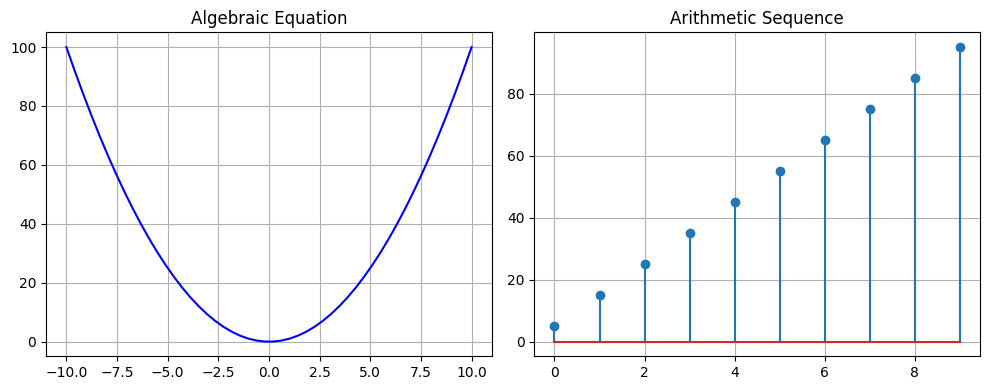

In [ ]:
# Algebra: Quadratic Plot
x = np.linspace(-10, 10, 50)
y = x**2

# Sequence: Arithmetic (a=5, d=10)
terms = np.array([5 + (i * 10) for i in range(10)])

plt.figure(figsize=(10, 4))

# Plot 1
plt.subplot(1, 2, 1)
plt.plot(x, y, color='blue', label='y = x^2')
plt.title('Algebraic Equation')
plt.grid(True)

# Plot 2
plt.subplot(1, 2, 2)
plt.stem(range(len(terms)), terms)
plt.title('Arithmetic Sequence')
plt.grid(True)

plt.tight_layout()
plt.show()

# Dynamic Math Dashboard
Select a dataset and visualization type by changing the `choice` variable below.

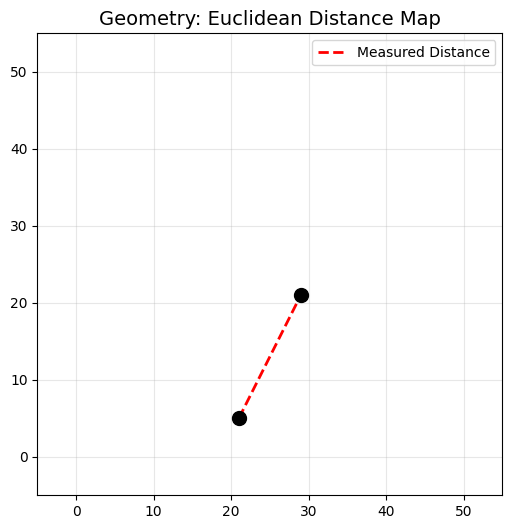

In [ ]:
# @title Interactive Math Dashboard { run: "auto" }
# @markdown Select a visualization category from the dropdown to update the plot automatically.

choice = "Geometry (Euclidean Distance Map)" # @param ["Algebraic (Quadratic vs Linear)", "Sequences (Arithmetic vs Fibonacci)", "Geometry (Euclidean Distance Map)"]

if choice == "Algebraic (Quadratic vs Linear)":
    x = np.linspace(-10, 10, 100)
    plt.figure(figsize=(7, 4))
    plt.plot(x, 2*x + 5, label='Linear (2x+5)', color='#1f77b4', linewidth=2)
    plt.plot(x, x**2 - 4, label='Quadratic (x²-4)', color='#d62728', linewidth=2)
    plt.title("Algebraic Function Comparison", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

elif choice == "Sequences (Arithmetic vs Fibonacci)":
    n = 5 # @param {type:"slider", min:5, max:20, step:1}
    arith = [5 + (i * 10) for i in range(n)]
    fib = [0, 1]
    for i in range(2, n): fib.append(fib[-1] + fib[-2])

    plt.figure(figsize=(7, 4))
    plt.plot(range(n), arith, 'o-', label='Arithmetic', markersize=8)
    plt.plot(range(n), fib, 's-', label='Fibonacci', markersize=8)
    plt.title(f"Sequence Comparison (n={n})", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

elif choice == "Geometry (Euclidean Distance Map)":
    num_points = 2 # @param {type:"slider", min:2, max:10, step:1}
    pts = np.random.randint(0, 50, (num_points, 2))
    plt.figure(figsize=(6, 6))
    plt.scatter(pts[:,0], pts[:,1], c='black', s=100, zorder=3)
    # Draw connection between first two points
    plt.plot([pts[0,0], pts[1,0]], [pts[0,1], pts[1,1]], 'r--', linewidth=2, label='Measured Distance')
    plt.title("Geometry: Euclidean Distance Map", fontsize=14)
    plt.xlim(-5, 55); plt.ylim(-5, 55)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Interactive Dataset Explorer
Select a dataset (Iris/Wine) and a plot type to visualize the data distribution.

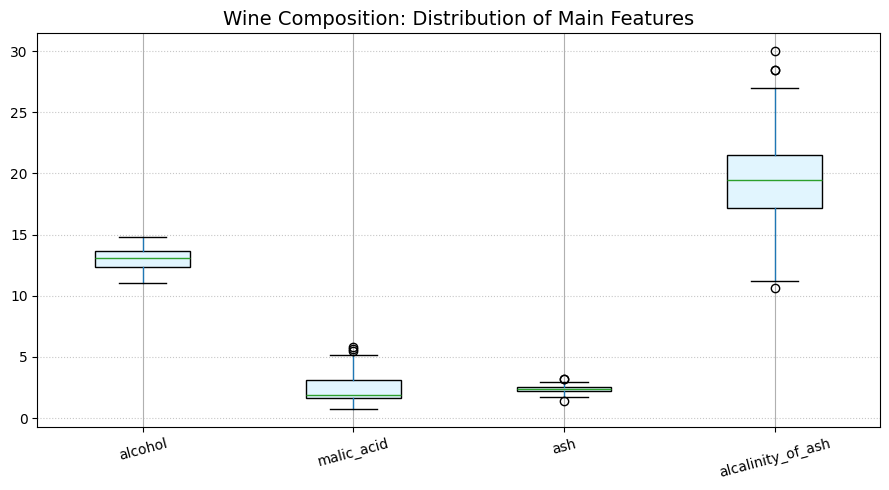

In [ ]:
# @title Interactive Dataset Explorer { run: "auto" }
# @markdown Choose a dataset and a visualization style to explore data distributions.

dataset = "wine" # @param ["iris", "wine"]
plot_type = "box" # @param ["scatter", "box", "histogram"]
color_theme = "magma" # @param ["viridis", "magma", "plasma", "inferno"]

# 1. Load Selected Dataset
if dataset == 'iris':
    raw_data = load_iris()
    title_name = "Iris Flowers"
else:
    raw_data = load_wine()
    title_name = "Wine Composition"

df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
df['target'] = raw_data.target

# 2. Render Plot
plt.figure(figsize=(9, 5))

if plot_type == 'scatter':
    sc = plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df['target'], cmap=color_theme, s=60, edgecolors='white', alpha=0.8)
    plt.title(f"{title_name}: {df.columns[0]} vs {df.columns[1]}", fontsize=14)
    plt.xlabel(df.columns[0])
    plt.ylabel(df.columns[1])
    plt.colorbar(sc, label='Target Class')

elif plot_type == 'box':
    df.iloc[:, :4].boxplot(patch_artist=True, boxprops=dict(facecolor='#e1f5fe'))
    plt.title(f"{title_name}: Distribution of Main Features", fontsize=14)
    plt.xticks(rotation=15)

elif plot_type == 'histogram':
    feature_idx = 0 # @param {type:"integer"}
    feature_idx = max(0, min(feature_idx, 3))
    plt.hist(df.iloc[:, feature_idx], bins=15, color='#64b5f6', edgecolor='white')
    plt.title(f"{title_name}: Distribution of {df.columns[feature_idx]}", fontsize=14)
    plt.xlabel(df.columns[feature_idx])
    plt.ylabel("Frequency")

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()